# Slice-Type Classification Evaluation — ORION Intent-to-Slice Pipeline

This notebook evaluates the ORION pipeline's **3GPP slice-type classification** across multiple LLM providers.

**Data source:** `src/test/validated_outputs/` — raw pipeline outputs containing the full SDK responses from each LLM provider.
**Ground truth:** `src/test/intent_dataset.csv` — expected 3GPP slice types per intent.

**Evaluation:** Deterministic comparison of predicted vs. ground-truth slice type (eMBB / uRRLC / mMTC). No LLM judge required.

**Models evaluated:**
- Anthropic: Claude Opus 4.5, Claude Sonnet 4.5
- OpenAI: GPT-5, GPT-5 Nano
- Google: Gemini 3 Pro Preview, Gemini 3 Flash Preview

In [10]:
%pip install -q pandas matplotlib seaborn numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Load & Normalize Results

Each provider CSV in `src/test/validated_outputs/` contains raw SDK response objects. We parse them to extract:
- **`predicted_slice_type`** — the LLM's 3GPP slice-type classification (eMBB / uRRLC / mMTC)
- **`policy_status`** — success/failure of the Slice API policy creation
- **`policy_json`** — the full JSON policy response for the LLM judge

Ground-truth slice types are loaded from `src/test/intent_dataset.csv` and joined by intent text.

In [11]:
import os
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Enable inline plotting
%matplotlib inline

# Set consistent plot style (matching llm_analysis.ipynb)
sns.set_theme(style='whitegrid', font_scale=1.7)

BASE_DIR = Path("/home/gustavo/orion-near-rt/analysis/classification_accuracy")
VALIDATED_DIR = BASE_DIR / "validated_outputs"
DATASET_PATH = BASE_DIR / "intent_dataset.csv"

# ── Ground-truth dataset (intent_id ; slice_type ; intent) ──────────────
ground_truth = pd.read_csv(DATASET_PATH, sep=";")
intent_to_slice = dict(zip(ground_truth["intent"].str.strip(), ground_truth["slice_type"].str.strip()))
print(f"Ground-truth intents loaded: {len(intent_to_slice)}")
print(f"Slice types: {ground_truth['slice_type'].unique()}")

# ── Filename → model name mapping ──────────────────────────────────────
FILE_MODEL_MAP = {
    "anthropic-opus-4-5.csv":       "claude-opus-4-5",
    "anthropic-sonnet-4-5.csv":     "claude-sonnet-4-5",
    "openai-gpt-5.csv":             "gpt-5",
    "openai-gpt-5-nano.csv":        "gpt-5-nano",
    "gemini-3-flash-preview.csv":   "gemini-3-flash-preview",
    "gemini-3-pro-preview.csv":     "gemini-3-pro-preview",
}

# ── Display names + colors (matching llm_analysis.ipynb) ─────────────────
MODEL_DISPLAY_MAP = {
    "claude-opus-4-5": "Claude Opus 4.5",
    "claude-sonnet-4-5": "Claude Sonnet 4.5",
    "gemini-3-flash-preview": "Gemini 3 Flash",
    "gemini-3-pro-preview": "Gemini 3 Pro",
    "gpt-5-nano": "GPT-5 Nano",
    "gpt-5": "GPT-5",
}

MODEL_COLORS = {
    "Claude Opus 4.5": "#B39DDB",   # Purple (Anthropic)
    "Claude Sonnet 4.5": "#CE93D8", # Light Purple (Anthropic)
    "Gemini 3 Flash": "#90CAF9",    # Light Blue (Google)
    "Gemini 3 Pro": "#64B5F6",      # Blue (Google)
    "GPT-5 Nano": "#A5D6A7",        # Light Green (OpenAI)
    "GPT-5": "#81C784",             # Green (OpenAI)
}

MODEL_ORDER = list(MODEL_COLORS.keys())
SLICE_COLORS = {"eMBB": "#64B5F6", "uRRLC": "#FFCC80", "mMTC": "#81C784"}

# ── Parsing helpers ─────────────────────────────────────────────────────

_SLICE_RE = re.compile(r"text='(eMBB|uR[RL]LC|mMTC)'")
_TOOL_RE  = re.compile(r"name='(create_session)'")

def extract_policy_status(policy_str: str) -> str:
    """Parse the policy JSON and return the status string."""
    if not isinstance(policy_str, str) or not policy_str.strip():
        return "Failed"
    try:
        obj = json.loads(policy_str)
        return obj.get("status", "Failed")
    except (json.JSONDecodeError, TypeError):
        return "Failed"

def extract_slice_type(type_def: str) -> str:
    """Extract eMBB / uRRLC / mMTC from the type_definition SDK repr."""
    if not isinstance(type_def, str):
        return ""
    m = _SLICE_RE.search(type_def)
    if m:
        val = m.group(1)
        return "uRRLC" if val == "uRLLC" else val  # normalize
    return ""

def extract_tool_called(intent_proc: str) -> str:
    """Extract tool name from the intent_processing SDK repr."""
    if not isinstance(intent_proc, str):
        return ""
    m = _TOOL_RE.search(intent_proc)
    return m.group(1) if m else ""

# ── Load all validated_outputs CSVs ─────────────────────────────────────
frames = []
for filename, model_name in FILE_MODEL_MAP.items():
    fpath = VALIDATED_DIR / filename
    if not fpath.exists():
        print(f"  ✗ Missing {filename}")
        continue

    df = pd.read_csv(fpath)

    parsed = pd.DataFrame({
        "intent":              df["intent"].astype(str).str.strip(),
        "model":               model_name,
        "tool_called":         df["intent_processing"].apply(extract_tool_called),
        "policy_json":         df["policy"].fillna("").astype(str),
        "policy_status":       df["policy"].fillna("").astype(str).apply(extract_policy_status),
        "predicted_slice_type": df["type_definition"].fillna("").astype(str).apply(extract_slice_type),
        "source_file":         filename,
    })
    frames.append(parsed)

    n_ok = (parsed["policy_status"] == "Policy created successfully").sum()
    print(f"  ✓ {filename} → {model_name}: {len(parsed)} intents, {n_ok} successful policies")

intent_results = pd.concat(frames, ignore_index=True)

# ── Add display names for consistent ordering and colors ─────────────────
intent_results["model_display"] = intent_results["model"].map(MODEL_DISPLAY_MAP).fillna(intent_results["model"])

# ── Join ground-truth slice type ────────────────────────────────────────
intent_results["expected_slice_type"] = intent_results["intent"].map(intent_to_slice)
n_matched = intent_results["expected_slice_type"].notna().sum()
print(f"\nGround-truth matched: {n_matched}/{len(intent_results)} rows")

print(f"Total rows: {len(intent_results)}")
print(f"Models: {intent_results['model'].unique().tolist()}")
print(f"Predicted slice types: {intent_results['predicted_slice_type'].value_counts().to_dict()}")
print(f"Expected slice types:  {intent_results['expected_slice_type'].value_counts().to_dict()}")

intent_results[["intent", "model", "predicted_slice_type", "expected_slice_type", "policy_status"]].head(5)

Ground-truth intents loaded: 100
Slice types: ['eMBB' 'uRRLC' 'mMTC']
  ✓ anthropic-opus-4-5.csv → claude-opus-4-5: 101 intents, 101 successful policies
  ✓ anthropic-sonnet-4-5.csv → claude-sonnet-4-5: 100 intents, 17 successful policies
  ✓ openai-gpt-5.csv → gpt-5: 100 intents, 100 successful policies
  ✓ openai-gpt-5-nano.csv → gpt-5-nano: 100 intents, 97 successful policies
  ✓ gemini-3-flash-preview.csv → gemini-3-flash-preview: 100 intents, 66 successful policies
  ✓ gemini-3-pro-preview.csv → gemini-3-pro-preview: 100 intents, 78 successful policies

Ground-truth matched: 601/601 rows
Total rows: 601
Models: ['claude-opus-4-5', 'claude-sonnet-4-5', 'gpt-5', 'gpt-5-nano', 'gemini-3-flash-preview', 'gemini-3-pro-preview']
Predicted slice types: {'eMBB': 168, 'uRRLC': 153, '': 142, 'mMTC': 138}
Expected slice types:  {'eMBB': 205, 'uRRLC': 198, 'mMTC': 198}


,intent,model,predicted_slice_type,expected_slice_type,policy_status
0,Create a slice to support video journalists tr...,claude-opus-4-5,eMBB,eMBB,Policy created successfully
1,Provision a slice for a university campus even...,claude-opus-4-5,eMBB,eMBB,Policy created successfully
2,Set up a slice for a shopping mall to improve ...,claude-opus-4-5,eMBB,eMBB,Policy created successfully
3,Deploy a slice for a media production crew usi...,claude-opus-4-5,eMBB,eMBB,Policy created successfully
4,Establish a slice for commuters in a busy trai...,claude-opus-4-5,eMBB,eMBB,Policy created successfully


## 2. Slice-Type Classification Accuracy

Deterministic comparison: `predicted_slice_type == expected_slice_type` for each intent.

In [12]:
# ── Compute match: predicted vs ground-truth ────────────────────────────
intent_results["slice_match"] = (
    intent_results["predicted_slice_type"] == intent_results["expected_slice_type"]
)

# ── Per-model accuracy ──────────────────────────────────────────────────
comparison_df = intent_results.groupby("model").agg(
    total=("intent", "count"),
    correct=("slice_match", "sum"),
    has_prediction=("predicted_slice_type", lambda s: (s != "").sum()),
).reset_index()

comparison_df["accuracy_%"] = (comparison_df["correct"] / comparison_df["total"] * 100).round(1)
comparison_df["prediction_rate_%"] = (comparison_df["has_prediction"] / comparison_df["total"] * 100).round(1)

# Add display names and enforce consistent ordering
comparison_df["model_display"] = comparison_df["model"].map(MODEL_DISPLAY_MAP).fillna(comparison_df["model"])
model_order = [m for m in MODEL_ORDER if m in comparison_df["model_display"].values]
comparison_df["model_display"] = pd.Categorical(
    comparison_df["model_display"], categories=model_order, ordered=True
)
comparison_df = comparison_df.sort_values("model_display")

comparison_df[["model_display", "total", "has_prediction", "correct", "accuracy_%", "prediction_rate_%"]]

,model_display,total,has_prediction,correct,accuracy_%,prediction_rate_%
0,Claude Opus 4.5,101,101,100,99.0,100.0
1,Claude Sonnet 4.5,100,17,13,13.0,17.0
2,Gemini 3 Flash,100,66,66,66.0,66.0
3,Gemini 3 Pro,100,78,77,77.0,78.0
5,GPT-5 Nano,100,97,90,90.0,97.0
4,GPT-5,100,100,96,96.0,100.0


## 3. Visualizations

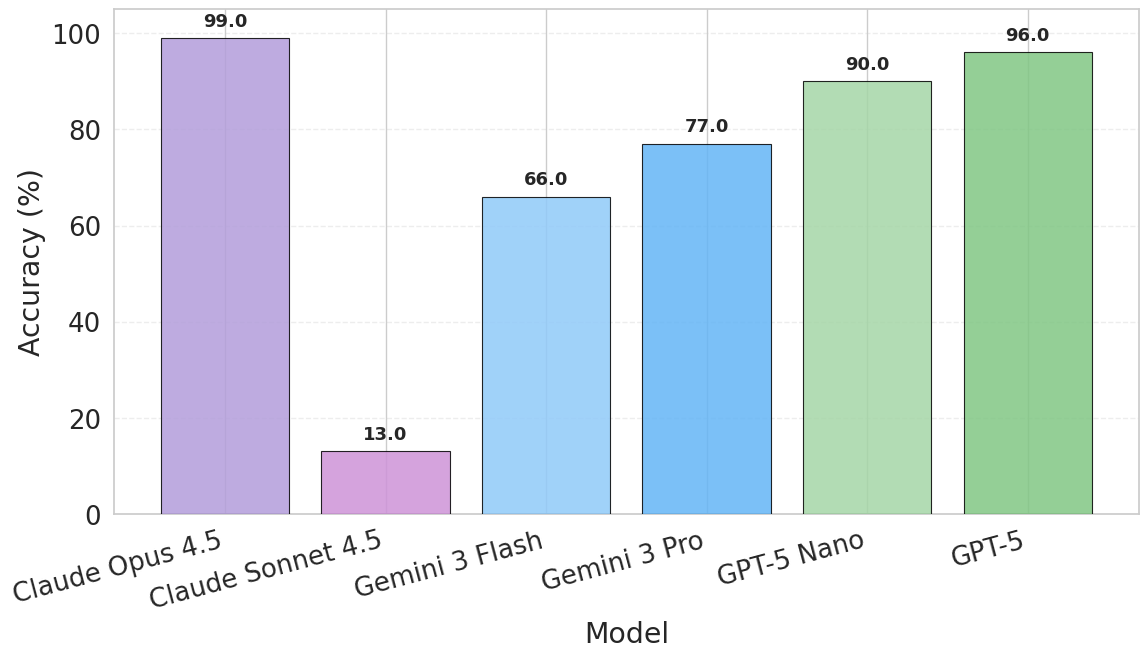


✓ Chart saved to: slice_type_accuracy_by_model.png


In [13]:
# ── 4a. Slice-Type Classification Accuracy per Model ───────────────────
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(comparison_df))
colors = [MODEL_COLORS.get(m, "#9E9E9E") for m in comparison_df["model_display"]]
bars = ax.bar(
    x,
    comparison_df["accuracy_%"],
    color=colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
 )

ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Model")
ax.set_ylim(0, 105)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["model_display"], rotation=15, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)

for bar, val in zip(bars, comparison_df["accuracy_%"]):
    ax.annotate(
        f"{val:.1f}",
        xy=(bar.get_x() + bar.get_width() / 2, val),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("slice_type_accuracy_by_model.png", dpi=300, bbox_inches="tight")
plt.savefig("slice_type_accuracy_by_model.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: slice_type_accuracy_by_model.png")

In [14]:
# ── 4a (Table). Slice-Type Classification Accuracy per Model ─────────────
accuracy_table = comparison_df[
    ["model_display", "total", "has_prediction", "correct", "accuracy_%", "prediction_rate_%"]
].rename(columns={
    "model_display": "Model",
    "total": "Total",
    "has_prediction": "Has Prediction",
    "correct": "Correct",
    "accuracy_%": "Accuracy (%)",
    "prediction_rate_%": "Prediction Rate (%)",
})

accuracy_table

,Model,Total,Has Prediction,Correct,Accuracy (%),Prediction Rate (%)
0,Claude Opus 4.5,101,101,100,99.0,100.0
1,Claude Sonnet 4.5,100,17,13,13.0,17.0
2,Gemini 3 Flash,100,66,66,66.0,66.0
3,Gemini 3 Pro,100,78,77,77.0,78.0
5,GPT-5 Nano,100,97,90,90.0,97.0
4,GPT-5,100,100,96,96.0,100.0


## 6. Example Paragraph for Scientific Paper

> **Evaluation Methodology.**
> To assess the accuracy of the 3GPP slice-type classification performed by the ORION pipeline, we compare each model's predicted slice type against ground-truth labels provided by domain experts. Each natural-language intent in the evaluation dataset is annotated with the correct slice category—enhanced Mobile Broadband (eMBB), Ultra-Reliable Low-Latency Communication (URLLC), or massive Machine-Type Communication (mMTC)—based on the throughput, latency, and device-density requirements expressed in the intent. The predicted slice type, extracted from the LLM's type-definition response, is compared deterministically against this label. We report per-model classification accuracy overall and stratified by slice type, along with confusion matrices to identify systematic misclassification patterns. This evaluation covers all six models under test (Claude Opus 4.5, Claude Sonnet 4.5, GPT-5, GPT-5 Nano, Gemini 3 Pro Preview, and Gemini 3 Flash Preview) across 100 intents each.